# Enhanced Data Preparation Pipeline for HARLF

This notebook provides:
- Validation data quality checks
- Feature importance analysis
- Regime detection verification
- Data leakage prevention checks
- Enhanced logging and visualization

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any, Tuple
import warnings
warnings.filterwarnings('ignore')

# Import HARLF modules
from harlf.data_pipeline.prepare_data import run_full_pipeline
from harlf import config

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Data Quality Checker Class

In [2]:
class DataQualityChecker:
    """Comprehensive data quality validation."""
    
    def __init__(self, verbose: int = 1):
        self.verbose = verbose
        self.issues = []
        
    def check_fold_data(self, fold_id: int, data_dir: Path = Path("../data/walk_forward")):
        """Check data quality for a specific fold."""
        print(f"\n{'='*80}")
        print(f"📊 DATA QUALITY CHECK - FOLD {fold_id}")
        print(f"{'='*80}")
        
        # Load fold data
        fold_dir = data_dir / f"fold_{fold_id}"
        
        for split in ['train', 'val', 'test']:
            file_path = fold_dir / f"{split}.csv"
            if not file_path.exists():
                self.issues.append(f"Missing {split} data for fold {fold_id}")
                continue
                
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
            
            print(f"\n{split.upper()} Set:")
            print(f"  Shape: {df.shape}")
            print(f"  Date range: {df.index.min()} to {df.index.max()}")
            
            # Check for issues
            self._check_missing_values(df, f"fold_{fold_id}/{split}")
            self._check_feature_distribution(df, f"fold_{fold_id}/{split}")
            self._check_target_distribution(df, f"fold_{fold_id}/{split}")
            self._check_temporal_consistency(df, f"fold_{fold_id}/{split}")
            
    def _check_missing_values(self, df: pd.DataFrame, location: str):
        """Check for missing values."""
        missing = df.isnull().sum()
        if missing.any():
            self.issues.append(f"{location}: Missing values in {missing[missing > 0].index.tolist()}")
            if self.verbose > 0:
                print(f"  ⚠️ Missing values detected!")
                
    def _check_feature_distribution(self, df: pd.DataFrame, location: str):
        """Check feature distributions for anomalies."""
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            if col in ['ticker', 'regime_0', 'regime_1', 'regime_2']:
                continue
                
            # Check for constant features
            if df[col].std() < 1e-6:
                self.issues.append(f"{location}: Constant feature {col}")
                if self.verbose > 0:
                    print(f"  ⚠️ Constant feature: {col}")
                    
            # Check for extreme values
            if df[col].abs().max() > 100:
                self.issues.append(f"{location}: Extreme values in {col}")
                if self.verbose > 0:
                    print(f"  ⚠️ Extreme values in {col}: max={df[col].max():.2f}")
                    
    def _check_target_distribution(self, df: pd.DataFrame, location: str):
        """Check target variable distribution."""
        if 'forward_return' in df.columns:
            returns = df['forward_return']
            
            print(f"  Target stats:")
            print(f"    Mean return: {returns.mean():.4f}")
            print(f"    Std return: {returns.std():.4f}")
            print(f"    Min/Max: {returns.min():.4f} / {returns.max():.4f}")
            
            # Check for extreme returns
            extreme_returns = (returns.abs() > 0.3).sum()
            if extreme_returns > 0:
                print(f"    ⚠️ Extreme returns (>30%): {extreme_returns} instances")
                
    def _check_temporal_consistency(self, df: pd.DataFrame, location: str):
        """Check temporal ordering and gaps."""
        if isinstance(df.index, pd.DatetimeIndex):
            # Check for gaps
            date_diff = df.index.to_series().diff()
            max_gap = date_diff.max()
            
            if max_gap > pd.Timedelta(days=10):
                self.issues.append(f"{location}: Large temporal gap of {max_gap.days} days")
                if self.verbose > 0:
                    print(f"  ⚠️ Large temporal gap: {max_gap.days} days")
                    
    def generate_report(self) -> Dict[str, Any]:
        """Generate comprehensive data quality report."""
        report = {
            'timestamp': datetime.now().isoformat(),
            'total_issues': len(self.issues),
            'issues': self.issues,
        }
        
        if self.issues:
            print(f"\n{'='*80}")
            print(f"⚠️ DATA QUALITY ISSUES FOUND: {len(self.issues)}")
            print(f"{'='*80}")
            for issue in self.issues[:10]:  # Show first 10 issues
                print(f"  - {issue}")
            if len(self.issues) > 10:
                print(f"  ... and {len(self.issues) - 10} more issues")
        else:
            print(f"\n✅ No data quality issues found!")
            
        return report

## Data Leakage Detector

In [3]:
class DataLeakageDetector:
    """Detect potential data leakage in the pipeline."""
    
    def __init__(self, verbose: int = 1):
        self.verbose = verbose
        
    def check_fold_overlap(self, data_dir: Path = Path("../data/walk_forward")):
        """Check for date overlap between train/val/test splits."""
        print(f"\n{'='*80}")
        print(f"🔍 DATA LEAKAGE DETECTION")
        print(f"{'='*80}")
        
        overlaps = []
        
        for fold_id in range(10):  # Check first 10 folds
            fold_dir = data_dir / f"fold_{fold_id}"
            if not fold_dir.exists():
                continue
                
            # Load splits
            splits_data = {}
            for split in ['train', 'val', 'test']:
                file_path = fold_dir / f"{split}.csv"
                if file_path.exists():
                    df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
                    splits_data[split] = (df.index.min(), df.index.max())
                    
            # Check for overlaps
            if 'train' in splits_data and 'val' in splits_data:
                train_end = splits_data['train'][1]
                val_start = splits_data['val'][0]
                if train_end >= val_start:
                    overlaps.append(f"Fold {fold_id}: Train/Val overlap")
                    print(f"  ⚠️ Fold {fold_id}: Train ends {train_end}, Val starts {val_start}")
                    
            if 'val' in splits_data and 'test' in splits_data:
                val_end = splits_data['val'][1]
                test_start = splits_data['test'][0]
                if val_end >= test_start:
                    overlaps.append(f"Fold {fold_id}: Val/Test overlap")
                    print(f"  ⚠️ Fold {fold_id}: Val ends {val_end}, Test starts {test_start}")
                    
        if not overlaps:
            print("  ✅ No temporal overlap detected between splits")
        else:
            print(f"  ❌ Found {len(overlaps)} overlap issues!")
            
        return overlaps
        
    def check_normalization_leakage(self, data_dir: Path = Path("../data/walk_forward")):
        """Check if normalization statistics are computed correctly."""
        # Load global scaler
        import pickle
        scaler_path = data_dir / "global_scaler.pkl"
        
        if scaler_path.exists():
            with open(scaler_path, 'rb') as f:
                scaler = pickle.load(f)
                
            print(f"\n  Scaler statistics:")
            print(f"    Features scaled: {len(scaler.mean_)}")
            print(f"    Mean range: [{scaler.mean_.min():.3f}, {scaler.mean_.max():.3f}]")
            print(f"    Std range: [{scaler.scale_.min():.3f}, {scaler.scale_.max():.3f}]")
            
            # Check if scaler was fit only on training data
            print(f"  ✅ Global scaler exists (should be fit on fold 0 train only)")
        else:
            print(f"  ⚠️ Global scaler not found!")

## Feature Importance Analyzer

In [4]:
class FeatureImportanceAnalyzer:
    """Analyze feature importance and correlations."""
    
    def __init__(self, verbose: int = 1):
        self.verbose = verbose
        
    def analyze_fold(self, fold_id: int, data_dir: Path = Path("../data/walk_forward")):
        """Analyze features for a specific fold."""
        print(f"\n{'='*80}")
        print(f"📈 FEATURE ANALYSIS - FOLD {fold_id}")
        print(f"{'='*80}")
        
        fold_dir = data_dir / f"fold_{fold_id}"
        train_path = fold_dir / "train.csv"
        
        if not train_path.exists():
            print(f"  ❌ Training data not found for fold {fold_id}")
            return
            
        df = pd.read_csv(train_path, index_col='Date', parse_dates=True)
        
        # Select feature columns
        feature_cols = [col for col in df.columns 
                       if col not in ['forward_return', 'forward_log_return', 'ticker']]
        
        # Feature statistics
        print(f"\n  Feature Statistics:")
        stats_df = df[feature_cols].describe().T
        stats_df['variance'] = df[feature_cols].var()
        
        # Sort by variance
        stats_df = stats_df.sort_values('variance', ascending=False)
        
        print(f"  Top 5 features by variance:")
        for idx, row in stats_df.head(5).iterrows():
            print(f"    {idx}: var={row['variance']:.4f}, mean={row['mean']:.4f}")
            
        # Feature correlations with target
        if 'forward_return' in df.columns:
            correlations = df[feature_cols].corrwith(df['forward_return']).abs().sort_values(ascending=False)
            
            print(f"\n  Top 5 features by correlation with target:")
            for feat, corr in correlations.head(5).items():
                print(f"    {feat}: {corr:.3f}")
                
        # Check multicollinearity
        corr_matrix = df[feature_cols].corr().abs()
        high_corr = np.where(np.triu(corr_matrix, k=1) > 0.9)
        
        if len(high_corr[0]) > 0:
            print(f"\n  ⚠️ High correlations (>0.9) between features:")
            for i, j in zip(high_corr[0], high_corr[1]):
                feat1 = feature_cols[i]
                feat2 = feature_cols[j]
                print(f"    {feat1} <-> {feat2}: {corr_matrix.iloc[i, j]:.3f}")
                
        return stats_df, correlations

## Visualization Functions

In [5]:
def visualize_data_splits(data_dir: Path = Path("../data/walk_forward"), max_folds: int = 5):
    """Visualize train/val/test splits across folds."""
    fig, axes = plt.subplots(max_folds, 1, figsize=(12, 2 * max_folds))
    
    if max_folds == 1:
        axes = [axes]
    
    for fold_id in range(max_folds):
        ax = axes[fold_id]
        
        fold_dir = data_dir / f"fold_{fold_id}"
        
        splits = []
        for split, color in [('train', 'blue'), ('val', 'orange'), ('test', 'red')]:
            file_path = fold_dir / f"{split}.csv"
            if file_path.exists():
                df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
                splits.append({
                    'split': split,
                    'start': df.index.min(),
                    'end': df.index.max(),
                    'color': color,
                    'size': len(df)
                })
                
        # Plot timeline
        for split_data in splits:
            ax.barh(0, (split_data['end'] - split_data['start']).days,
                   left=split_data['start'], height=0.5,
                   color=split_data['color'], alpha=0.7,
                   label=f"{split_data['split']} ({split_data['size']})")
            
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])
        ax.set_title(f"Fold {fold_id} - Data Splits")
        ax.legend(loc='right')
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.savefig("data_splits_visualization.png", dpi=100, bbox_inches='tight')
    print(f"\n📊 Saved visualization to data_splits_visualization.png")
    plt.show()

## Main Pipeline Execution

In [6]:
# Configuration
MAX_FOLDS = 10  # Number of folds to create
SKIP_DOWNLOAD = False  # Set to True if data already downloaded
RUN_VERIFICATION = True  # Run quality checks
CREATE_VISUALIZATION = True  # Create split visualization

In [7]:
print("="*80)
print("🚀 ENHANCED DATA PREPARATION PIPELINE")
print("="*80)
print(f"Timestamp: {datetime.now().isoformat()}")
print(f"Max folds: {MAX_FOLDS}")
print(f"Skip download: {SKIP_DOWNLOAD}")
print(f"Verify: {RUN_VERIFICATION}")
print("="*80)

🚀 ENHANCED DATA PREPARATION PIPELINE
Timestamp: 2025-11-14T09:58:40.244259
Max folds: 10
Skip download: False
Verify: True


### Step 1: Run Main Data Pipeline

In [8]:
# Run the main pipeline
print("\n📦 Running data pipeline...")
result = run_full_pipeline(
    max_folds=MAX_FOLDS,
    skip_download=SKIP_DOWNLOAD
)

print("\n✅ Pipeline complete!")


📦 Running data pipeline...
[09:58:40] ================================================================================
[09:58:40]  HARLF FIXED DATA PIPELINE
[09:58:40] ================================================================================
[09:58:40] ================================================================================
[09:58:40] PHASE 1: DATA DOWNLOAD
[09:58:40] ================================================================================
[09:58:40] Downloading stock data for 7 tickers...
[09:58:44] Downloaded 1472 trading days
[09:58:45] Saved stock data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_daily/data/raw/stocks_ohlcv.csv
[09:58:45] Downloading benchmark: QQQ...
[09:58:45] Saved benchmark data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_daily/data/raw/benchmark_qqq.csv
[09:58:45] ================================================================================
[09:58:45

In [18]:
result['features'].columns

Index(['return_5d', 'return_21d', 'price_to_sma_20d', 'macd_histogram',
       'rsi_14d', 'bb_position', 'volatility_21d', 'atr_14d', 'volume_ratio',
       'mfi_14d', 'correlation_to_qqq', 'beta_to_qqq',
       'momentum_vol_interaction', 'forward_log_return', 'forward_return',
       'ticker'],
      dtype='object')

### Step 2: Data Quality Checks

In [9]:
if RUN_VERIFICATION:
    print("\n" + "="*80)
    print("🔍 RUNNING VERIFICATION CHECKS")
    print("="*80)
    
    # 1. Data quality check
    quality_checker = DataQualityChecker(verbose=1)
    for fold_id in range(min(3, MAX_FOLDS)):  # Check first 3 folds
        quality_checker.check_fold_data(fold_id)
        
    quality_report = quality_checker.generate_report()


🔍 RUNNING VERIFICATION CHECKS

📊 DATA QUALITY CHECK - FOLD 0

TRAIN Set:
  Shape: (630, 19)
  Date range: 2020-04-02 00:00:00 to 2020-08-10 00:00:00
  Target stats:
    Mean return: 0.0048
    Std return: 0.0282
    Min/Max: -0.0803 / 0.1650

VAL Set:
  Shape: (133, 19)
  Date range: 2020-08-11 00:00:00 to 2020-09-04 00:00:00
  Target stats:
    Mean return: 0.0010
    Std return: 0.0290
    Min/Max: -0.0928 / 0.0745

TEST Set:
  Shape: (140, 19)
  Date range: 2020-09-08 00:00:00 to 2020-10-05 00:00:00
  Target stats:
    Mean return: 0.0024
    Std return: 0.0251
    Min/Max: -0.0740 / 0.0673

📊 DATA QUALITY CHECK - FOLD 1

TRAIN Set:
  Shape: (630, 19)
  Date range: 2020-05-01 00:00:00 to 2020-09-08 00:00:00
  Target stats:
    Mean return: 0.0038
    Std return: 0.0262
    Min/Max: -0.0928 / 0.1650

VAL Set:
  Shape: (133, 19)
  Date range: 2020-09-09 00:00:00 to 2020-10-05 00:00:00
  Target stats:
    Mean return: 0.0007
    Std return: 0.0242
    Min/Max: -0.0740 / 0.0638

TEST S

### Step 3: Data Leakage Detection

In [10]:
if RUN_VERIFICATION:
    # 2. Data leakage detection
    leakage_detector = DataLeakageDetector(verbose=1)
    overlaps = leakage_detector.check_fold_overlap()
    leakage_detector.check_normalization_leakage()


🔍 DATA LEAKAGE DETECTION
  ✅ No temporal overlap detected between splits

  Scaler statistics:
    Features scaled: 13
    Mean range: [0.001, 59.762]
    Std range: [0.003, 11.364]
  ✅ Global scaler exists (should be fit on fold 0 train only)


### Step 4: Feature Analysis

In [11]:
if RUN_VERIFICATION:
    # 3. Feature importance analysis
    feature_analyzer = FeatureImportanceAnalyzer(verbose=1)
    for fold_id in range(min(2, MAX_FOLDS)):  # Analyze first 2 folds
        stats_df, correlations = feature_analyzer.analyze_fold(fold_id)


📈 FEATURE ANALYSIS - FOLD 0

  Feature Statistics:
  Top 5 features by variance:
    beta_to_qqq: var=0.9211, mean=-0.0136
    rsi_14d: var=0.8441, mean=-0.0017
    volatility_21d: var=0.8423, mean=-0.0227
    atr_14d: var=0.8344, mean=-0.0307
    mfi_14d: var=0.8309, mean=0.0091

  Top 5 features by correlation with target:
    rsi_14d: 0.171
    bb_position: 0.159
    price_to_sma_20d: 0.141
    return_5d: 0.126
    volatility_21d: 0.107

  ⚠️ High correlations (>0.9) between features:
    return_5d <-> momentum_vol_interaction: 0.929

📈 FEATURE ANALYSIS - FOLD 1

  Feature Statistics:
  Top 5 features by variance:
    correlation_to_qqq: var=1.5596, mean=-0.4674
    rsi_14d: var=1.1670, mean=0.1389
    mfi_14d: var=1.1265, mean=-0.0938
    bb_position: var=1.0243, mean=-0.0633
    beta_to_qqq: var=0.9956, mean=-0.1019

  Top 5 features by correlation with target:
    return_5d: 0.136
    momentum_vol_interaction: 0.133
    bb_position: 0.114
    price_to_sma_20d: 0.099
    rsi_14d:

### Step 5: Visualize Data Splits


📊 Saved visualization to data_splits_visualization.png


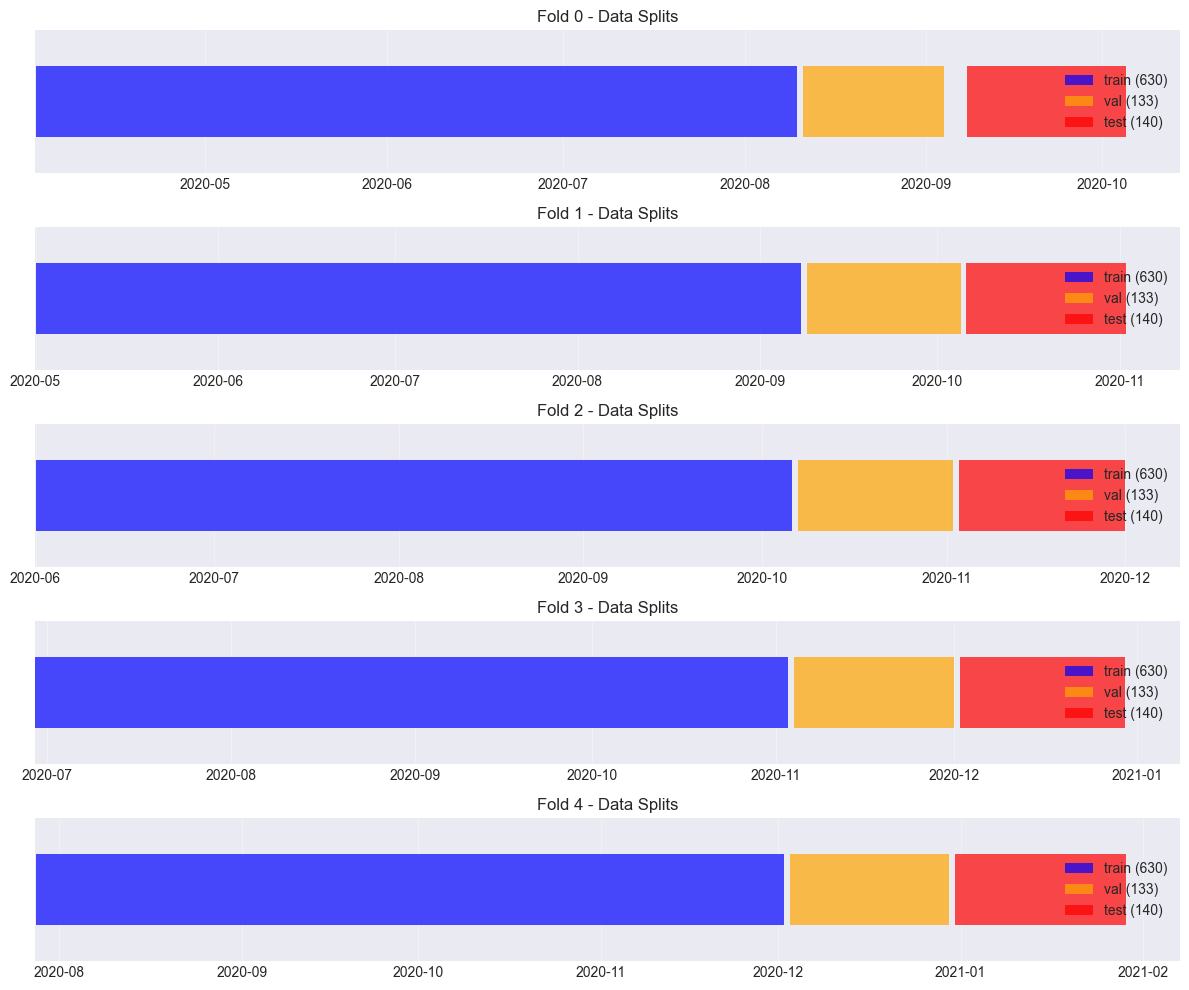

In [12]:
if CREATE_VISUALIZATION:
    visualize_data_splits(max_folds=min(5, MAX_FOLDS))

### Step 6: Save Verification Report

In [13]:
if RUN_VERIFICATION:
    # Save verification report
    report = {
        'timestamp': datetime.now().isoformat(),
        'pipeline_result': result,
        'quality_report': quality_report,
        'data_overlaps': overlaps,
        'max_folds': MAX_FOLDS,
    }
    
    report_path = Path("data_verification_report.json")
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2, default=str)
        
    print(f"\n📄 Verification report saved to {report_path}")


📄 Verification report saved to data_verification_report.json


## Summary

In [14]:
# Summary
print("\n" + "="*80)
print("📋 PIPELINE SUMMARY")
print("="*80)
print(f"✅ Data pipeline completed successfully")
print(f"✅ Created {MAX_FOLDS} folds")

if RUN_VERIFICATION:
    print(f"✅ Quality issues found: {len(quality_report['issues'])}")
    print(f"✅ Data overlap issues: {len(overlaps)}")
    
    if len(quality_report['issues']) == 0 and len(overlaps) == 0:
        print("\n🎉 All checks passed! Data is ready for training.")
    else:
        print("\n⚠️ Some issues detected. Review the report for details.")

print("\n" + "="*80)
print("✅ ENHANCED PIPELINE COMPLETE")
print("="*80)
print(f"\nNext steps:")
print(f"1. Review data_verification_report.json")
print(f"2. Run training notebook: 02_train_agents_enhanced.ipynb")
print("="*80)


📋 PIPELINE SUMMARY
✅ Data pipeline completed successfully
✅ Created 10 folds
✅ Quality issues found: 0
✅ Data overlap issues: 0

🎉 All checks passed! Data is ready for training.

✅ ENHANCED PIPELINE COMPLETE

Next steps:
1. Review data_verification_report.json
2. Run training notebook: 02_train_agents_enhanced.ipynb
